# 1. Cài đặt & Import (Chung)

In [1]:
# Cài đặt thư viện (Đã thêm pandarallel và tqdm)
!pip install pandas seaborn matplotlib wordcloud underthesea pandarallel tqdm

# Imports cho toàn bộ notebook
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
import re
import unicodedata
from difflib import SequenceMatcher
from collections import defaultdict
import logging
from typing import List, Dict, Optional, Tuple
from pandarallel import pandarallel # (ĐÃ SỬA LỖI IMPORT)
from tqdm.auto import tqdm # Thêm import TQDM
import warnings

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("✓ Cài đặt & Imports hoàn tất.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.6/978.6 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 96.4 MB/s eta 0:00:00
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16674 sha256=bd0c1812e6ede53fcd961bab6571a05bba24f0dd1ee97941676b7e11d731f504
  Stored in directory: /root/.cache/pip/wheels/b9/c6/5a/829298789e94348b81af52ab42c19d49da007306bbcc983827
Successfully built pandarallel
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts

# 2. Thiết lập Đường dẫn & Tạo Thư mục

In [2]:
# Đường dẫn tới dataset bạn vừa thêm (ĐÃ CẬP NHẬT)
KAGGLE_INPUT_PATH = '/kaggle/input/tmg-rawdata/data' 

# Tạo thư mục output (ĐÃ SỬA LỖI)
KAGGLE_WORKING_PATH = '/kaggle/working/'
FIGURES_PATH = os.path.join(KAGGLE_WORKING_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)

# Định nghĩa đường dẫn file dữ liệu
TEENCODE_PATH = os.path.join(KAGGLE_INPUT_PATH, 'teencode_dict.json')
TRAIN_PATH = os.path.join(KAGGLE_INPUT_PATH, 'train_set.csv')
VAL_PATH = os.path.join(KAGGLE_INPUT_PATH, 'val_set.csv')
TEST_PATH = os.path.join(KAGGLE_INPUT_PATH, 'test_set.csv')

print(f"✓ Đường dẫn dữ liệu đã sẵn sàng. Teencode tại: {TEENCODE_PATH}")
print(f"✓ Thư mục figures tại: {FIGURES_PATH}")

✓ Đường dẫn dữ liệu đã sẵn sàng. Teencode tại: /kaggle/input/tmg-rawdata/data/teencode_dict.json
✓ Thư mục figures tại: /kaggle/working/figures


# 3. Preprocessing Data

In [3]:
# --- BẮT ĐẦU CODE TIỀN XỬ LÝ ---

class VietnameseTextPreprocessor:
    """Preprocessing pipeline for Vietnamese text"""

    def __init__(self, config: Dict):
        """
        Initialize preprocessor with configuration

        Args:
            config: Dictionary containing preprocessing settings
        """
        self.config = config
        self.preprocessing_config = config.get('preprocessing', {})

        # Load teencode dictionary
        # Sửa lại: Không dùng default path, luôn lấy từ config
        teencode_path = self.preprocessing_config.get('teencode_dict_path') 
        if not teencode_path:
             logger.error("Không tìm thấy 'teencode_dict_path' trong config['preprocessing']!")
             self.teencode_dict = {}
        else:
             self.teencode_dict = self._load_teencode_dict(teencode_path)

        # Compile regex patterns
        self._compile_patterns()

        logger.info("VietnameseTextPreprocessor initialized")

    def _load_teencode_dict(self, path: str) -> Dict[str, str]:
        """Load teencode dictionary from JSON file"""
        try:
            with open(path, 'r', encoding='utf-8') as f:
                return json.load(f)
        except FileNotFoundError:
            logger.warning(f"Teencode dictionary not found at {path}. Using empty dict.")
            return {}

    def _compile_patterns(self):
        """Compile regex patterns for efficiency"""
        # URL pattern
        self.url_pattern = re.compile(
            r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
            r'|www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
            r'|(?:[a-zA-Z0-9-]+\.)+(?:com|vn|net|org|edu|gov|mil|int|info|biz|name|museum|coop|aero|asia|jobs|mobi|travel|xxx)'
        )

        # Number pattern
        self.number_pattern = re.compile(r'\b\d+(?:[.,]\d+)*\b')

        # Emoji pattern (Unicode emoji ranges)
        self.emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F"  # emoticons
            "\U0001F300-\U0001F5FF"  # symbols & pictographs
            "\U0001F680-\U0001F6FF"  # transport & map symbols
            "\U0001F1E0-\U0001F1FF"  # flags (iOS)
            "\U00002702-\U000027B0"
            "\U000024C2-\U0001F251"
            "\U0001F900-\U0001F9FF"  # supplemental symbols
            "\U0001FA00-\U0001FA6F"  # extended symbols
            "]+", 
            flags=re.UNICODE
        )

        # Punctuation pattern for normalization
        self.multiple_punct_pattern = re.compile(r'([!?.,;:])(\1{2,})')

        # Multiple spaces pattern
        self.multiple_space_pattern = re.compile(r'\s+')

        # Vietnamese sentence splitting pattern
        self.sentence_split_pattern = re.compile(r'(?<=[.!?])\s+(?=[A-ZĐÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬÈÉẺẼẸÊỀẾỂỄỆÌÍỈĨỊÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢÙÚỦŨỤƯỪỨỬỮỰỲÝỶỸỴ])')

    def normalize_punctuation(self, text: str) -> str:
        """
        Normalize punctuation marks
        - Limit consecutive punctuation to max 3
        - Normalize common Vietnamese punctuation
        """
        if not self.preprocessing_config.get('normalize_punctuation', True):
            return text

        max_consecutive = self.preprocessing_config.get('max_consecutive_punct', 3)

        # Replace multiple consecutive punctuation
        text = self.multiple_punct_pattern.sub(lambda m: m.group(1) * min(len(m.group(2)) + 1, max_consecutive), text)

        # Normalize Vietnamese punctuation
        text = text.replace('…', '...')
        text = text.replace('–', '-')
        text = text.replace('—', '-')
        text = text.replace('"', '"').replace('"', '"')
        text = text.replace(''', "'").replace(''', "'")

        return text

    def map_special_tokens(self, text: str) -> str:
        """
        Map URLs, numbers, and emojis to special tokens
        """
        # Map URLs
        if self.preprocessing_config.get('map_urls', True):
            url_token = self.preprocessing_config.get('url_token', '<URL>')
            text = self.url_pattern.sub(url_token, text)

        # Map numbers
        if self.preprocessing_config.get('map_numbers', True):
            number_token = self.preprocessing_config.get('number_token', '<NUM>')
            text = self.number_pattern.sub(number_token, text)

        # Map emojis
        if self.preprocessing_config.get('map_emojis', True):
            emoji_token = self.preprocessing_config.get('emoji_token', '<EMOJI>')
            text = self.emoji_pattern.sub(emoji_token, text)

        return text

    def handle_teencode(self, text: str) -> str:
        """
        Replace teencode words with standard Vietnamese
        Uses word boundary matching to avoid partial replacements
        """
        if not self.preprocessing_config.get('handle_teencode', True):
            return text

        if not self.teencode_dict:
            return text

        # Split into words
        words = text.split()

        # Replace teencode words
        processed_words = []
        for word in words:
            # Check if word (lowercase) is in teencode dict
            lower_word = word.lower()
            if lower_word in self.teencode_dict:
                processed_words.append(self.teencode_dict[lower_word])
            else:
                processed_words.append(word)

        return ' '.join(processed_words)

    def split_sentences(self, text: str) -> List[str]:
        """
        Split text into sentences (for error analysis)
        Uses Vietnamese sentence boundaries
        """
        if not self.preprocessing_config.get('split_sentences', True):
            return [text]

        sentences = self.sentence_split_pattern.split(text)
        # Clean up sentences
        sentences = [s.strip() for s in sentences if s.strip()]

        return sentences

    def normalize_text(self, text: str) -> str:
        """
        Main text normalization function
        - Lowercase (optional)
        - Keep Vietnamese tones
        - Normalize whitespace
        """
        # Lowercase
        if self.preprocessing_config.get('lowercase', True):
            text = text.lower()

        # Normalize whitespace
        text = self.multiple_space_pattern.sub(' ', text)
        text = text.strip()

        return text

    def preprocess_text(self, text: str, keep_sentences: bool = False) -> Tuple[str, Optional[List[str]]]:
        """
        Full preprocessing pipeline for a single text

        Args:
            text: Input text
            keep_sentences: Whether to return sentence splits

        Returns:
            Tuple of (processed_text, sentences_list or None)
        """
        if not isinstance(text, str):
            text = str(text)

        # Step 1: Normalize punctuation
        text = self.normalize_punctuation(text)

        # Step 2: Map special tokens (URL, NUM, EMOJI)
        text = self.map_special_tokens(text)

        # Step 3: Handle teencode
        text = self.handle_teencode(text)

        # Step 4: Normalize text (lowercase, whitespace)
        text = self.normalize_text(text)

        # Step 5: Split sentences if needed
        sentences = None
        if keep_sentences:
            sentences = self.split_sentences(text)
            # Rejoin sentences with separator
            sep_token = self.preprocessing_config.get('sentence_sep_token', ' [SEP] ')
            if sentences: # Chỉ join nếu list không rỗng
                text = sep_token.join(sentences)
            else:
                text = "" # Trả về chuỗi rỗng nếu không có câu nào

        return text, sentences

    def calculate_similarity(self, text1: str, text2: str) -> float:
        """
        Calculate similarity between two texts using SequenceMatcher
        """
        return SequenceMatcher(None, text1, text2).ratio()

    def deduplicate(self, df: pd.DataFrame, text_column: str = 'text') -> pd.DataFrame:
        """
        Deduplicate dataframe based on text similarity
        Uses fuzzy matching with ~95% threshold

        Args:
            df: Input dataframe
            text_column: Name of text column

        Returns:
            Deduplicated dataframe
        """
        if not self.preprocessing_config.get('dedup', True):
            return df

        threshold = self.preprocessing_config.get('dedup_threshold', 0.95)
        method = self.preprocessing_config.get('dedup_method', 'fuzzy')

        logger.info(f"Starting deduplication with method={method}, threshold={threshold}")

        if method == 'exact':
            # Simple exact match deduplication
            df_dedup = df.drop_duplicates(subset=[text_column])

        elif method == 'fuzzy':
            # Fuzzy deduplication
            texts = df[text_column].tolist()
            keep_indices = []
            seen_texts = []

            # Sửa đổi: Sử dụng tqdm cho vòng lặp deduplicate
            for idx, text in enumerate(tqdm(texts, desc=f"Deduplicating ({method})", leave=False)):
                # Check similarity with all seen texts
                is_duplicate = False
                for seen_text in seen_texts:
                    if self.calculate_similarity(text, seen_text) >= threshold:
                        is_duplicate = True
                        break

                if not is_duplicate:
                    keep_indices.append(idx)
                    seen_texts.append(text)

            df_dedup = df.iloc[keep_indices].reset_index(drop=True)

        else:
            logger.warning(f"Unknown dedup method: {method}. Skipping deduplication.")
            df_dedup = df

        logger.info(f"Deduplication: {len(df)} -> {len(df_dedup)} ({len(df) - len(df_dedup)} removed)")

        return df_dedup

    def preprocess_dataframe(self, df: pd.DataFrame, text_column: str = 'text') -> pd.DataFrame:
        """
        Preprocess entire dataframe
        ...
        """
        logger.info(f"Preprocessing {len(df)} texts...")

        df = df.copy()

        # Xử lý các giá trị NaN trong cột text trước
        df[text_column] = df[text_column].fillna("")

        processed_texts = []
        all_sentences = []

        # Lấy giá trị 'keep_sentences' từ config, default là True
        keep_sentences = self.preprocessing_config.get('keep_sentences', True)

        # Sửa đổi: Sử dụng tqdm cho vòng lặp
        for idx, text in enumerate(tqdm(df[text_column], desc="Preprocessing rows", leave=False)):
            processed_text, sentences = self.preprocess_text(text, keep_sentences=keep_sentences)
            processed_texts.append(processed_text)
            all_sentences.append(sentences)

        df[f'{text_column}_processed'] = processed_texts
        df['sentences'] = all_sentences
        df['num_sentences'] = [len(s) if s else 0 for s in all_sentences]

        df['text_length'] = df[f'{text_column}_processed'].str.len()
        df['num_words'] = df[f'{text_column}_processed'].str.split().str.len()

        min_length = self.preprocessing_config.get('min_length', 10)
        max_length = self.preprocessing_config.get('max_length', 5000)

        before_filter = len(df)
        df = df[(df['text_length'] >= min_length) & (df['text_length'] <= max_length)]
        logger.info(f"Length filter: {before_filter} -> {len(df)} ({before_filter - len(df)} removed)")

        df = self.deduplicate(df, f'{text_column}_processed')

        logger.info(f"Preprocessing complete. Final: {len(df)} texts")

        return df

In [4]:
class RobustnessChecker:
    """Check model robustness through augmentation tests"""

    def __init__(self, config: Dict):
        self.config = config.get('robustness', {})

    def replace_special_tokens(self, text: str, token_type: str = 'url') -> str:
        """Replace special tokens with placeholders"""
        if token_type == 'url':
            return re.sub(r'<URL>', 'example.com', text)
        elif token_type == 'number':
            return re.sub(r'<NUM>', '123', text)
        elif token_type == 'emoji':
            return re.sub(r'<EMOJI>', '😊', text)
        return text

    def permute_punctuation(self, text: str) -> List[str]:
        """Generate variations with different punctuation"""
        variations = [
            text,
            re.sub(r'[!?.,;:]', '', text),  # Remove all punctuation
            re.sub(r'\.', '!', text),  # Replace periods with exclamation
            re.sub(r'[!?]', '.', text),  # Normalize to periods
        ]
        return list(set(variations))

    def check_class_distribution(self, df: pd.DataFrame, label_col: str) -> Dict:
        """Check for class imbalance and small classes"""
        distribution = df[label_col].value_counts(normalize=True)

        threshold = self.config.get('min_class_ratio', 0.01)
        small_classes = distribution[distribution < threshold]

        return {
            'distribution': distribution.to_dict(),
            'small_classes': small_classes.to_dict(),
            'num_small_classes': len(small_classes)
        }

print("✓ Class VietnameseTextPreprocessor và RobustnessChecker đã được định nghĩa.")
# --- KẾT THÚC CODE TIỀN XỬ LÝ ---

✓ Class VietnameseTextPreprocessor và RobustnessChecker đã được định nghĩa.


# 4. Khởi tạo Preprocessor & Tải dữ liệu

In [5]:
# 1. Tải dataframes
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

# 2. Tạo config dict thủ công (thay vì dùng file .yaml)
# RẤT QUAN TRỌNG: Cung cấp đường dẫn teencode_dict_path
config = {
    'preprocessing': {
        'teencode_dict_path': TEENCODE_PATH,
        'lowercase': True,
        'normalize_punctuation': True,
        'map_urls': True,
        'map_numbers': True,
        'map_emojis': True,
        'handle_teencode': True,
        'split_sentences': True,        # Cần cho hàm preprocess_dataframe
        'keep_sentences': True,         # Tên cờ trong code của bạn
        'dedup': False,
        'dedup_method': 'fuzzy',
        'dedup_threshold': 0.95,
        'min_length': 10
    }
    # Thêm các key config khác nếu class của bạn cần
}

# 3. Khởi tạo preprocessor
preprocessor = VietnameseTextPreprocessor(config=config)

print(f"✓ Tải {len(train_df)} mẫu train, {len(val_df)} mẫu val.")
print(f"✓ Khởi tạo Preprocessor với teencode dict tại: {TEENCODE_PATH}")

# 4. Khởi tạo pandarallel (ĐÃ SỬA LỖI GỌI HÀM)
print("Khởi tạo Pandarallel (để tăng tốc xử lý)...")
# progress_bar=True sẽ hiển thị thanh tiến trình cho từng file
pandarallel.initialize(progress_bar=True) 
print("✓ Pandarallel đã sẵn sàng.")

✓ Tải 23048 mẫu train, 3305 mẫu val.
✓ Khởi tạo Preprocessor với teencode dict tại: /kaggle/input/tmg-rawdata/data/teencode_dict.json
Khởi tạo Pandarallel (để tăng tốc xử lý)...
INFO: Pandarallel will run on 2 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
✓ Pandarallel đã sẵn sàng.


# 5. Chạy Tiền xử lý (Dùng `preprocess_dataframe`)

In [6]:
print("Đang tiền xử lý (sử dụng multiprocessing)...")

# Lấy config
min_length = preprocessor.preprocessing_config.get('min_length', 10)
max_length = preprocessor.preprocessing_config.get('max_length', 5000)

def process_df(df, split_name):
    # Hàm này không log info bắt đầu/kết thúc nữa, tqdm sẽ lo việc đó

    # Xử lý các giá trị NaN trong cột text trước
    df['text'] = df['text'].fillna("")

    # --- PHẦN TĂNG TỐC ---
    # 1. Chạy parallel_apply để lấy tuple (processed_text, sentences)
    # 'keep_sentences=True' được lấy từ config trong preprocessor
    keep_sentences = preprocessor.preprocessing_config.get('keep_sentences', True)

    # Bọc hàm preprocess_text để truyền keep_sentences
    def text_processing_func(text):
        return preprocessor.preprocess_text(text, keep_sentences=keep_sentences)

    # Sử dụng parallel_apply
    # pandarallel sẽ tự hiển thị progress bar cho bước này
    results = df['text'].parallel_apply(text_processing_func)

    # 2. Tách tuple ra 2 cột
    df_processed = df.copy()
    df_processed['processed_tuple'] = results
    df_processed[['text_processed', 'sentences']] = pd.DataFrame(
        df_processed['processed_tuple'].tolist(), index=df_processed.index
    )

    # 3. Tính toán các cột thống kê
    df_processed['num_sentences'] = df_processed['sentences'].apply(lambda x: len(x) if x else 0)
    df_processed['text_length'] = df_processed['text_processed'].str.len()
    df_processed['num_words'] = df_processed['text_processed'].str.split().str.len()

    # 4. Lọc theo độ dài
    before_filter = len(df_processed)
    df_processed = df_processed[
        (df_processed['text_length'] >= min_length) & (df_processed['text_length'] <= max_length)
    ]
    logger.info(f"Length filter ({split_name}): {before_filter} -> {len(df_processed)} ({before_filter - len(df_processed)} removed)")

    # 5. Deduplicate
    df_processed = preprocessor.deduplicate(df_processed, 'text_processed')

    # Dọn dẹp cột tạm
    df_processed = df_processed.drop(columns=['processed_tuple'])

    # logger.info(f"✓ Xử lý {split_name} set hoàn tất. (Còn lại: {len(df_processed)} hàng)")
    return df_processed

# --- (THAY ĐỔI LỚN Ở ĐÂY) ---
# Chuẩn bị dataframes để xử lý
datasets = {
    "train": train_df,
    "val": val_df,
    "test": test_df
}

processed_datasets = {}

# Chạy xử lý cho từng set với TQDM (để thấy tiến trình 3 file)
print("Bắt đầu xử lý các data set...")
for split_name, df in tqdm(datasets.items(), desc="Processing datasets"):
    processed_datasets[split_name] = process_df(df, split_name)

# Gán lại vào biến
train_df_processed = processed_datasets["train"]
val_df_processed = processed_datasets["val"]
test_df_processed = processed_datasets["test"]
# --- (KẾT THÚC THAY ĐỔI) ---

print("\n✓ Tiền xử lý (multiprocessing) hoàn tất.")
print(train_df_processed[['text', 'text_processed', 'text_length']].head())

Đang tiền xử lý (sử dụng multiprocessing)...
Bắt đầu xử lý các data set...


Processing datasets:   0%|          | 0/3 [00:00<?, ?it/s]


✓ Tiền xử lý (multiprocessing) hoàn tất.
                                                text  \
0  em xin chào các anh chị em em là sinh viên vừa...   
1  xây dựng mô hình sư phạm chuẩn mực sáng tạo ti...   
2  sao lại ghét cái kiểu làm sai xong khóc lóc ăn...   
3  chào thầy đăng ký học ghép . môn học hiện hệ t...   
4                        con bé vẫn hoang mang lắm .   

                                      text_processed  text_length  
0  em xin chào các anh chị em em là sinh viên vừa...          486  
1  xây dựng mô hình sư phạm chuẩn mực sáng tạo ti...           56  
2  sao lại ghét cái kiểu làm sai xong khóc lóc ăn...          337  
3  chào thầy đăng ký học ghép . môn học hiện hệ t...          171  
4                        con bé vẫn hoang mang lắm .           27  


# 6. EDA - Setup & Chuẩn bị Dữ liệu

In [7]:
# --- BẮT ĐẦU EDA ---
print("Bắt đầu phân tích dữ liệu (EDA)...")

# Set style
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="husl")

# Đường dẫn lưu figures (đã định nghĩa ở Cell 2)
figures_dir = Path(FIGURES_PATH)

print(f"✓ Setup EDA hoàn tất. Figures sẽ được lưu vào: {figures_dir}")

Bắt đầu phân tích dữ liệu (EDA)...
✓ Setup EDA hoàn tất. Figures sẽ được lưu vào: /kaggle/working/figures


In [8]:
# --- Load Processed Data ---
# (SỬA LẠI: Dùng các dataframe đã xử lý ở Cell 5)

# Combine for overall analysis
train_df_processed['split'] = 'train'
val_df_processed['split'] = 'val'
test_df_processed['split'] = 'test'

all_data = pd.concat([train_df_processed, val_df_processed, test_df_processed], ignore_index=True)

print(f"Train: {len(train_df_processed)} samples")
print(f"Val: {len(val_df_processed)} samples")
print(f"Test: {len(test_df_processed)} samples")
print(f"Total: {len(all_data)} samples")

Train: 23033 samples
Val: 3302 samples
Test: 6609 samples
Total: 32944 samples


In [9]:
# --- Basic Statistics ---

# Display sample
print("\n=== Sample Data ===")
print(all_data[['text_processed', 'sentiment', 'classification', 'text_length', 'num_words']].head())

# Basic info
print("\n=== Data Info ===")
print(all_data.info())

# Summary statistics
print("\n=== Summary Statistics ===")
print(all_data[['text_length', 'num_words', 'num_sentences']].describe())


=== Sample Data ===
                                      text_processed  sentiment  \
0  em xin chào các anh chị em em là sinh viên vừa...        0.0   
1  xây dựng mô hình sư phạm chuẩn mực sáng tạo ti...        0.0   
2  sao lại ghét cái kiểu làm sai xong khóc lóc ăn...        2.0   
3  chào thầy đăng ký học ghép . môn học hiện hệ t...        0.0   
4                        con bé vẫn hoang mang lắm .        2.0   

   classification  text_length  num_words  
0             2.0          486        119  
1             2.0           56         13  
2             3.0          337         78  
3             2.0          171         40  
4             3.0           27          7  

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32944 entries, 0 to 32943
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   text            32944 non-null  object 
 1   sentiment       32944 non-null  float64
 2   

# 7. EDA - Phân tích Phân phối (Class Distribution)


Đang vẽ biểu đồ Phân phối Sentiment...


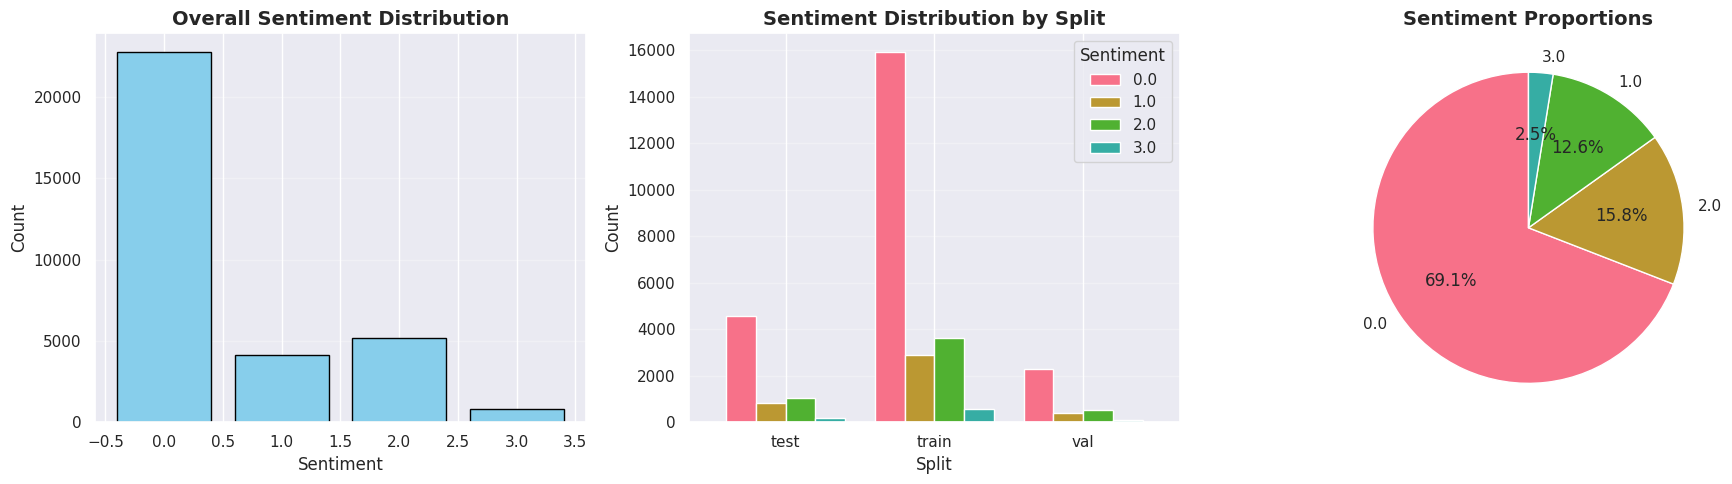


=== Sentiment Distribution ===
sentiment
0.0    22766
1.0     4146
2.0     5196
3.0      836
Name: count, dtype: int64

Proportions:
sentiment
0.0    0.691051
2.0    0.157722
1.0    0.125850
3.0    0.025376
Name: proportion, dtype: float64

Đang vẽ biểu đồ Phân phối Topic...


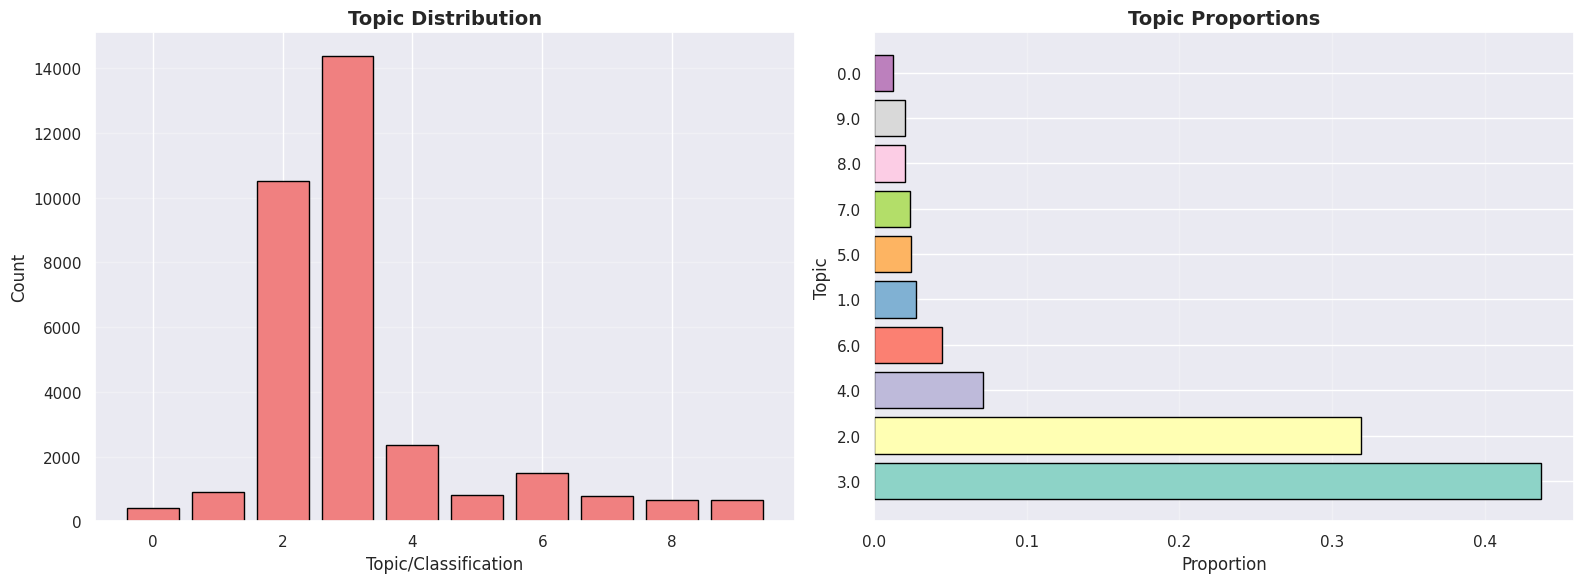


=== Topic Distribution ===
classification
0.0      405
1.0      900
2.0    10508
3.0    14388
4.0     2358
5.0      808
6.0     1477
7.0      769
8.0      669
9.0      662
Name: count, dtype: int64

Proportions:
classification
3.0    0.436741
2.0    0.318966
4.0    0.071576
6.0    0.044834
1.0    0.027319
5.0    0.024526
7.0    0.023343
8.0    0.020307
9.0    0.020095
0.0    0.012294
Name: proportion, dtype: float64


In [10]:
# --- 1. Class Distribution Analysis ---

print("\nĐang vẽ biểu đồ Phân phối Sentiment...")

### Sentiment Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall sentiment distribution
sentiment_counts = all_data['sentiment'].value_counts().sort_index()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Sentiment by split
sentiment_by_split = all_data.groupby(['split', 'sentiment']).size().unstack(fill_value=0)
sentiment_by_split.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_xlabel('Split', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Sentiment Distribution by Split', fontsize=14, fontweight='bold')
axes[1].legend(title='Sentiment')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

# Sentiment proportions
sentiment_prop = all_data['sentiment'].value_counts(normalize=True)
axes[2].pie(sentiment_prop.values, labels=sentiment_prop.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Sentiment Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show() # Hiển thị biểu đồ

print("\n=== Sentiment Distribution ===")
print(sentiment_counts)
print("\nProportions:")
print(sentiment_prop)

print("\nĐang vẽ biểu đồ Phân phối Topic...")

### Topic/Classification Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Topic distribution
topic_counts = all_data['classification'].value_counts().sort_index()
axes[0].bar(topic_counts.index, topic_counts.values, color='lightcoral', edgecolor='black')
axes[0].set_xlabel('Topic/Classification', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Topic Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Topic proportions
topic_prop = all_data['classification'].value_counts(normalize=True)
colors = plt.cm.Set3(range(len(topic_prop)))
axes[1].barh(topic_prop.index.astype(str), topic_prop.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Proportion', fontsize=12)
axes[1].set_ylabel('Topic', fontsize=12)
axes[1].set_title('Topic Proportions', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show() # Hiển thị biểu đồ

print("\n=== Topic Distribution ===")
print(topic_counts)
print("\nProportions:")
print(topic_prop)


# 8. EDA - Phân tích Mất cân bằng & Độ dài (Imbalance & Length)


=== Class Imbalance Analysis ===
Threshold for minor classes: 5.0%

Sentiment Classes:
   Sentiment 0.0: 69.11% ✓ OK
   Sentiment 2.0: 15.77% ✓ OK
   Sentiment 1.0: 12.58% ✓ OK
   Sentiment 3.0: 2.54% ⚠️ MINOR

Topic Classes:
   Topic 3.0: 43.67% ✓ OK
   Topic 2.0: 31.90% ✓ OK
   Topic 4.0: 7.16% ✓ OK
   Topic 6.0: 4.48% ⚠️ MINOR
   Topic 1.0: 2.73% ⚠️ MINOR
   Topic 5.0: 2.45% ⚠️ MINOR
   Topic 7.0: 2.33% ⚠️ MINOR
   Topic 8.0: 2.03% ⚠️ MINOR
   Topic 9.0: 2.01% ⚠️ MINOR
   Topic 0.0: 1.23% ⚠️ MINOR

Đang vẽ biểu đồ Phân tích Độ dài Văn bản...


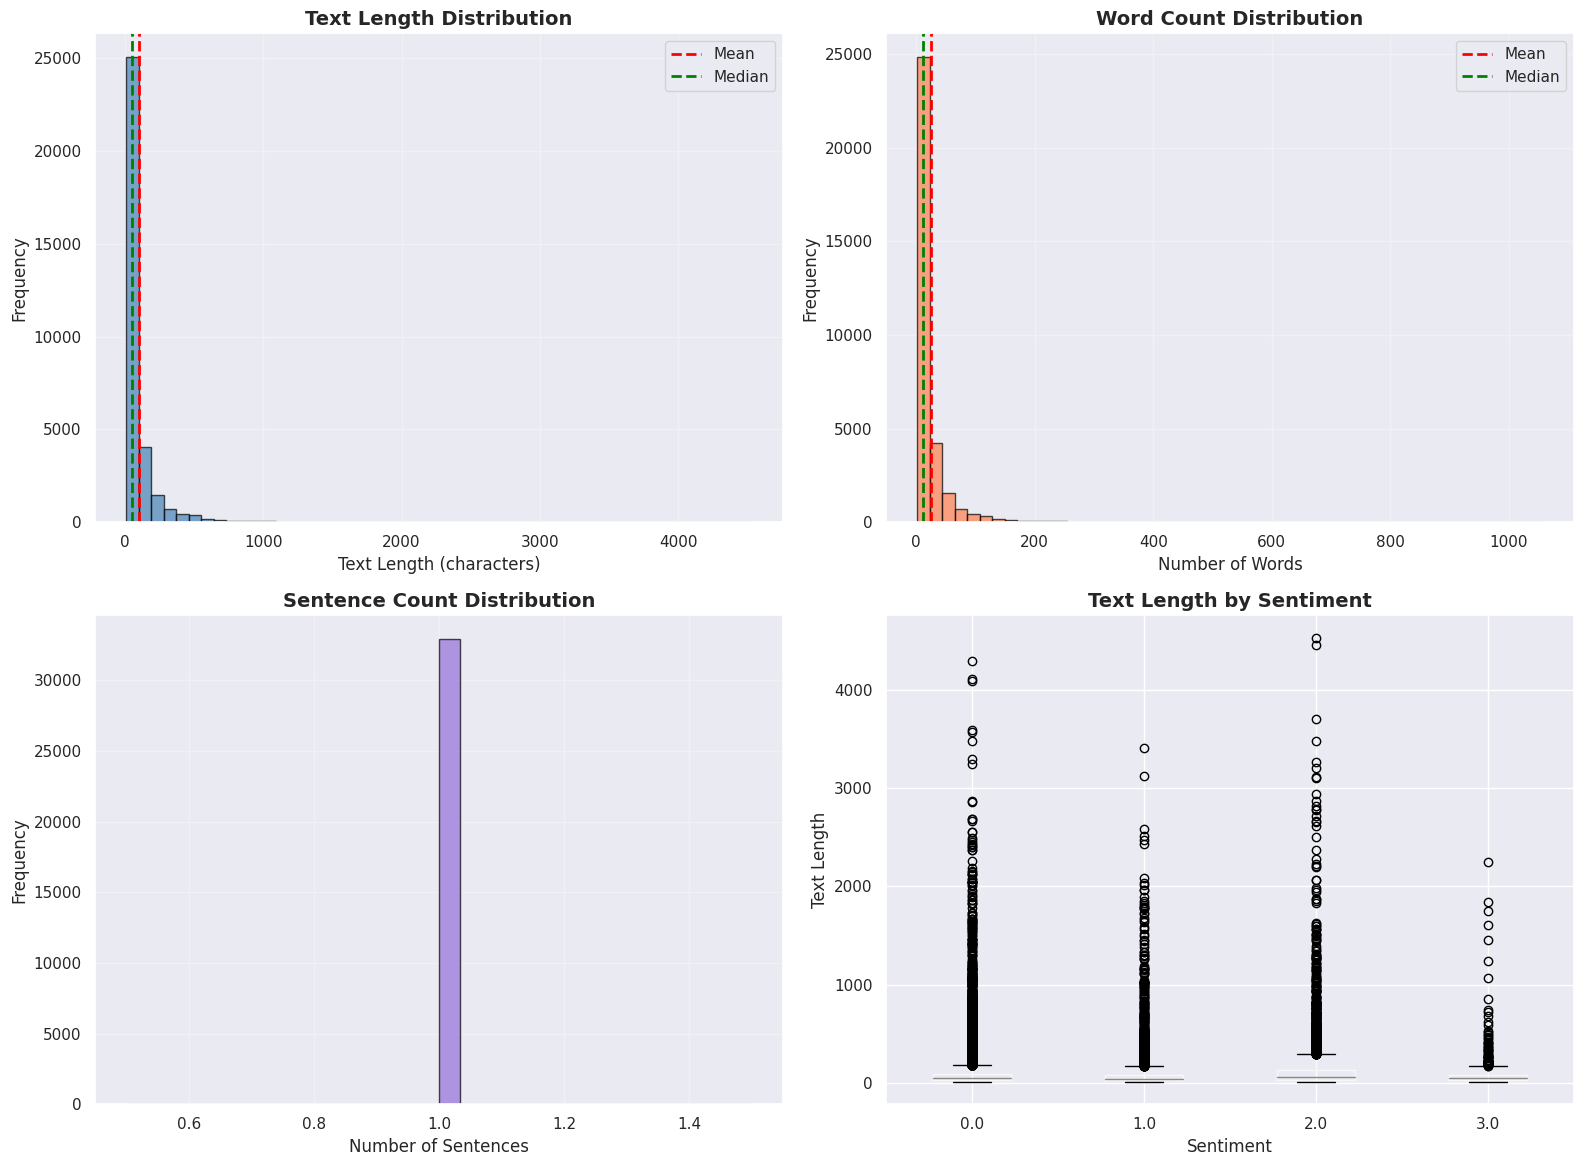


=== Text Length Statistics ===
Mean length: 105.08 characters
Median length: 49.00 characters
Mean words: 24.86
Mean sentences: 1.00


In [11]:
# --- 2. Class Imbalance Detection ---

# Mark minor classes (< 5%)
threshold = 0.05

print("\n=== Class Imbalance Analysis ===")
print(f"Threshold for minor classes: {threshold * 100}%\n")

# Sentiment imbalance
print("Sentiment Classes:")
for sent, prop in sentiment_prop.items():
    status = "⚠️ MINOR" if prop < threshold else "✓ OK"
    print(f"   Sentiment {sent}: {prop:.2%} {status}")

# Topic imbalance
print("\nTopic Classes:")
for topic, prop in topic_prop.items():
    status = "⚠️ MINOR" if prop < threshold else "✓ OK"
    print(f"   Topic {topic}: {prop:.2%} {status}")

# --- 3. Text Length Analysis ---

print("\nĐang vẽ biểu đồ Phân tích Độ dài Văn bản...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Text length distribution
axes[0, 0].hist(all_data['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Text Length (characters)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(all_data['text_length'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].axvline(all_data['text_length'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Word count distribution
axes[0, 1].hist(all_data['num_words'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of Words', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[0, 1].axvline(all_data['num_words'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].axvline(all_data['num_words'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Sentence count distribution
axes[1, 0].hist(all_data['num_sentences'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Number of Sentences', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Sentence Count Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Text length by sentiment
all_data.boxplot(column='text_length', by='sentiment', ax=axes[1, 1])
axes[1, 1].set_xlabel('Sentiment', fontsize=12)
axes[1, 1].set_ylabel('Text Length', fontsize=12)
axes[1, 1].set_title('Text Length by Sentiment', fontsize=14, fontweight='bold')
plt.suptitle('') # Tắt title tự động của boxplot
plt.sca(axes[1, 1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(figures_dir / 'text_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show() # Hiển thị biểu đồ

print("\n=== Text Length Statistics ===")
print(f"Mean length: {all_data['text_length'].mean():.2f} characters")
print(f"Median length: {all_data['text_length'].median():.2f} characters")
print(f"Mean words: {all_data['num_words'].mean():.2f}")
print(f"Mean sentences: {all_data['num_sentences'].mean():.2f}")

# 9. EDA - Phân tích Nâng cao & Báo cáo (Advanced Analysis & Report)


Đang vẽ biểu đồ Phân tích Sentiment theo Topic...


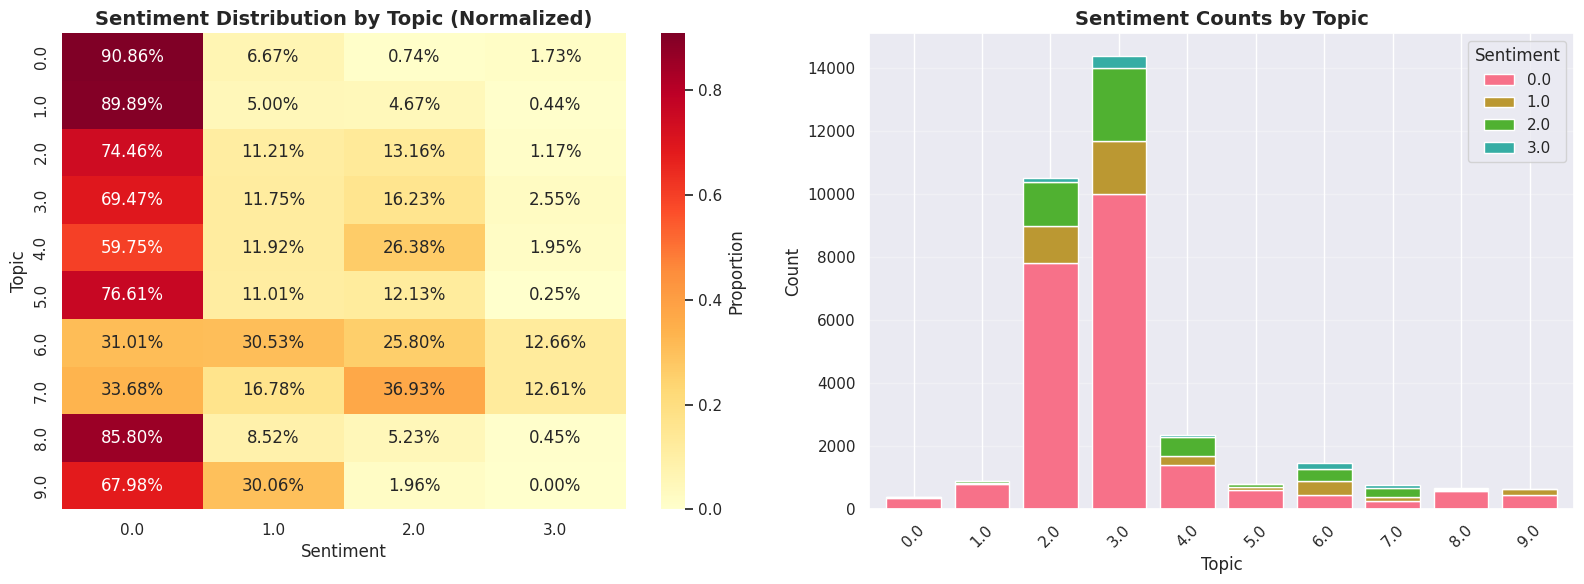


=== Sentiment by Topic ===
sentiment            0.0       1.0       2.0       3.0
classification                                        
0.0             0.908642  0.066667  0.007407  0.017284
1.0             0.898889  0.050000  0.046667  0.004444
2.0             0.744576  0.112105  0.131614  0.011705
3.0             0.694746  0.117459  0.162288  0.025507
4.0             0.597540  0.119169  0.263783  0.019508
5.0             0.766089  0.110149  0.121287  0.002475
6.0             0.310088  0.305349  0.257955  0.126608
7.0             0.336801  0.167750  0.369311  0.126138
8.0             0.857997  0.085202  0.052317  0.004484
9.0             0.679758  0.300604  0.019637  0.000000

=== Multi-Aspect Analysis ===

Number of unique sentiments per topic:
classification
0.0    4
1.0    4
2.0    4
3.0    4
4.0    4
5.0    4
6.0    4
7.0    4
8.0    4
9.0    3
Name: sentiment, dtype: int64

Multi-aspect ratio: 100.00%
Topics with multiple sentiments: 10/10

DATA QUALITY REPORT

1. Missing Value

In [12]:
# --- 4. Sentiment by Topic Analysis ---

print("\nĐang vẽ biểu đồ Phân tích Sentiment theo Topic...")

# Cross-tabulation
sentiment_by_topic = pd.crosstab(all_data['classification'], all_data['sentiment'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(sentiment_by_topic, annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Proportion'})
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Topic', fontsize=12)
axes[0].set_title('Sentiment Distribution by Topic (Normalized)', fontsize=14, fontweight='bold')

# Stacked bar chart
sentiment_by_topic_counts = pd.crosstab(all_data['classification'], all_data['sentiment'])
sentiment_by_topic_counts.plot(kind='bar', stacked=True, ax=axes[1], width=0.8)
axes[1].set_xlabel('Topic', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Sentiment Counts by Topic', fontsize=14, fontweight='bold')
axes[1].legend(title='Sentiment')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'sentiment_by_topic.png', dpi=300, bbox_inches='tight')
plt.show() # Hiển thị biểu đồ

print("\n=== Sentiment by Topic ===")
print(sentiment_by_topic)

# --- 5. Multi-Aspect Detection ---

print("\n=== Multi-Aspect Analysis ===")

# Group by topic and check sentiment variety
topic_sentiment_variety = all_data.groupby('classification')['sentiment'].nunique()
print("\nNumber of unique sentiments per topic:")
print(topic_sentiment_variety)

# Calculate multi-aspect ratio (topics with multiple sentiments)
multi_aspect_topics = (topic_sentiment_variety > 1).sum()
total_topics = len(topic_sentiment_variety)
multi_aspect_ratio = multi_aspect_topics / total_topics

print(f"\nMulti-aspect ratio: {multi_aspect_ratio:.2%}")
print(f"Topics with multiple sentiments: {multi_aspect_topics}/{total_topics}")

# --- 6. Data Quality Report ---

print("\n" + "=" * 80)
print("DATA QUALITY REPORT")
print("=" * 80)

# Missing values
print("\n1. Missing Values:")
print(all_data.isnull().sum())

# Duplicate check
# Lưu ý: 'text_processed' đã được deduplicate, 
# chúng ta kiểm tra 'all_data' (kết hợp) xem có trùng lặp không
print(f"\n2. Duplicates (raw combined): {all_data.duplicated(subset=['text', 'sentiment', 'classification']).sum()}")

# Text length outliers
q1 = all_data['text_length'].quantile(0.25)
q3 = all_data['text_length'].quantile(0.75)
iqr = q3 - q1
outliers = ((all_data['text_length'] < (q1 - 1.5 * iqr)) | (all_data['text_length'] > (q3 + 1.5 * iqr))).sum()
print(f"\n3. Text Length Outliers: {outliers} ({outliers/len(all_data)*100:.2f}%)")

# Class balance
print("\n4. Class Balance:")
print(f"   - Most common sentiment: {sentiment_counts.idxmax()} ({sentiment_counts.max()} samples)")
print(f"   - Least common sentiment: {sentiment_counts.idxmin()} ({sentiment_counts.min()} samples)")
print(f"   - Imbalance ratio (max/min): {sentiment_counts.max() / sentiment_counts.min():.2f}x")

print("\n" + "=" * 80)

# --- 7. Save Summary Statistics ---

summary_stats = {
    'total_samples': int(len(all_data)),
    'train_samples': int(len(train_df_processed)),
    'val_samples': int(len(val_df_processed)),
    'test_samples': int(len(test_df_processed)),
    'avg_text_length': float(all_data['text_length'].mean()),
    'avg_num_words': float(all_data['num_words'].mean()),
    'avg_num_sentences': float(all_data['num_sentences'].mean()),
    'sentiment_distribution': {str(k): int(v) for k, v in sentiment_counts.to_dict().items()},
    'topic_distribution': {str(k): int(v) for k, v in topic_counts.to_dict().items()},
    'minor_sentiment_classes': [int(k) for k, v in sentiment_prop.items() if v < threshold],
    'minor_topic_classes': [float(k) for k, v in topic_prop.items() if v < threshold],
    'multi_aspect_ratio': float(multi_aspect_ratio),
    'duplicates_raw_combined': int(all_data.duplicated(subset=['text', 'sentiment', 'classification']).sum()),
    'outliers': int(outliers)
}

summary_path = figures_dir / 'eda_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_stats, f, indent=2, ensure_ascii=False)

print(f"\n✓ EDA complete! All figures saved to {figures_dir}")
print(f"✓ Summary statistics saved to {summary_path}")
# --- KẾT THÚC EDA ---

# 10. Lưu lại Preprocessed Data

In [13]:
# Lưu các file đã xử lý để Notebook 2 sử dụng
TRAIN_PROCESSED_PATH = os.path.join(KAGGLE_WORKING_PATH, 'train_processed.csv')
VAL_PROCESSED_PATH = os.path.join(KAGGLE_WORKING_PATH, 'val_processed.csv')
TEST_PROCESSED_PATH = os.path.join(KAGGLE_WORKING_PATH, 'test_processed.csv')

# Lưu các dataframe đã qua xử lý
train_df_processed.to_csv(TRAIN_PROCESSED_PATH, index=False)
val_df_processed.to_csv(VAL_PROCESSED_PATH, index=False)
test_df_processed.to_csv(TEST_PROCESSED_PATH, index=False)

print(f"✓ Đã lưu 3 file processed vào: {KAGGLE_WORKING_PATH}")

✓ Đã lưu 3 file processed vào: /kaggle/working/
